# Random Forest

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE

In [32]:
glass=pd.read_csv("glass.csv")
glass

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [33]:
#display dataset
glass.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


# EDA

In [34]:
glass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [35]:
glass.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [36]:
glass.shape

(214, 10)

In [37]:
glass.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [38]:
glass.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [39]:
glass.duplicated().sum()

np.int64(1)

# Data Visualization

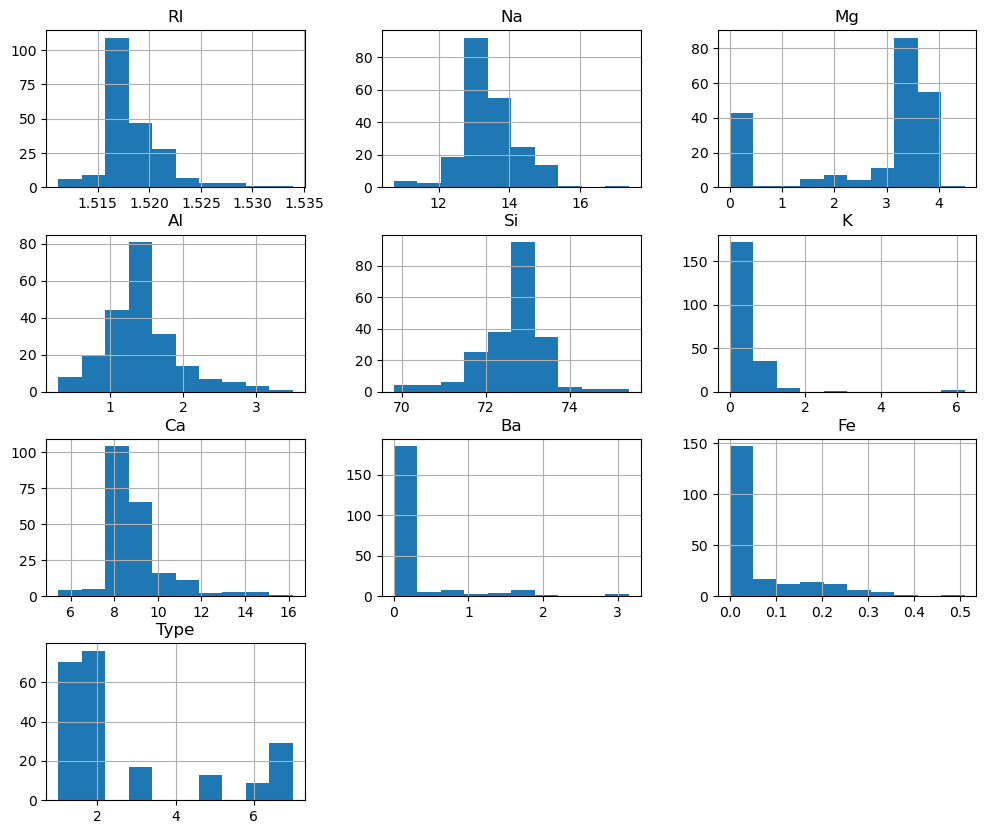

In [40]:
#histogram
glass.hist(figsize=(12,10))
plt.show()

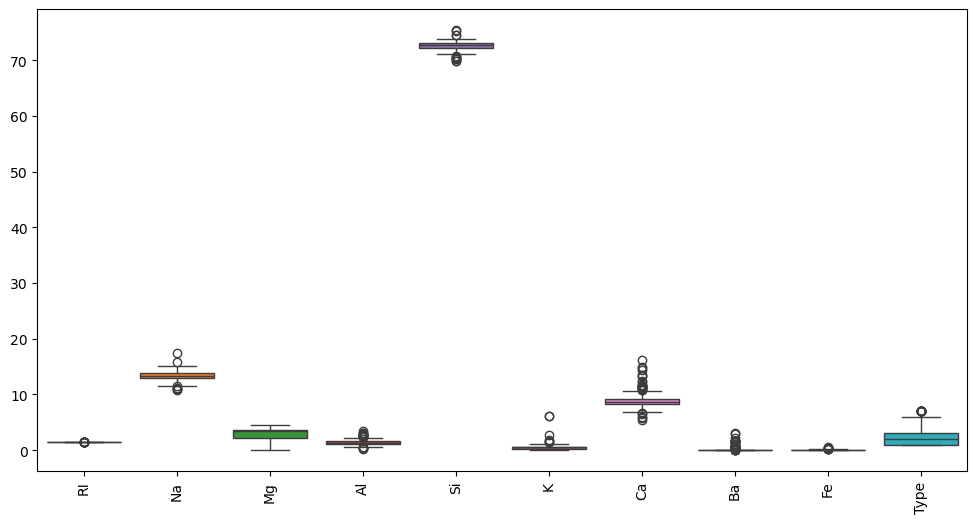

In [41]:
#boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=glass)
plt.xticks(rotation=90)
plt.show()

# Scatterplot

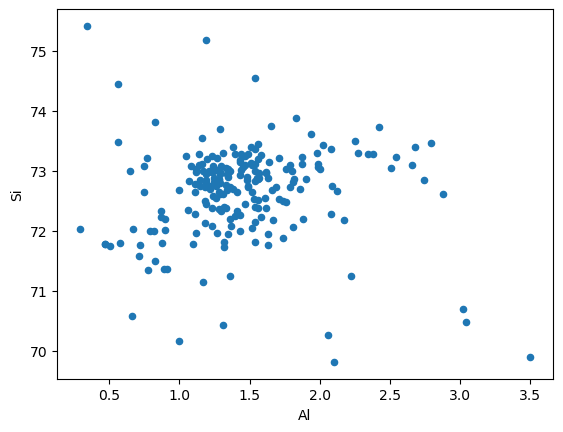

In [42]:
glass.plot(kind='scatter',x='Al',y='Si')
plt.show()

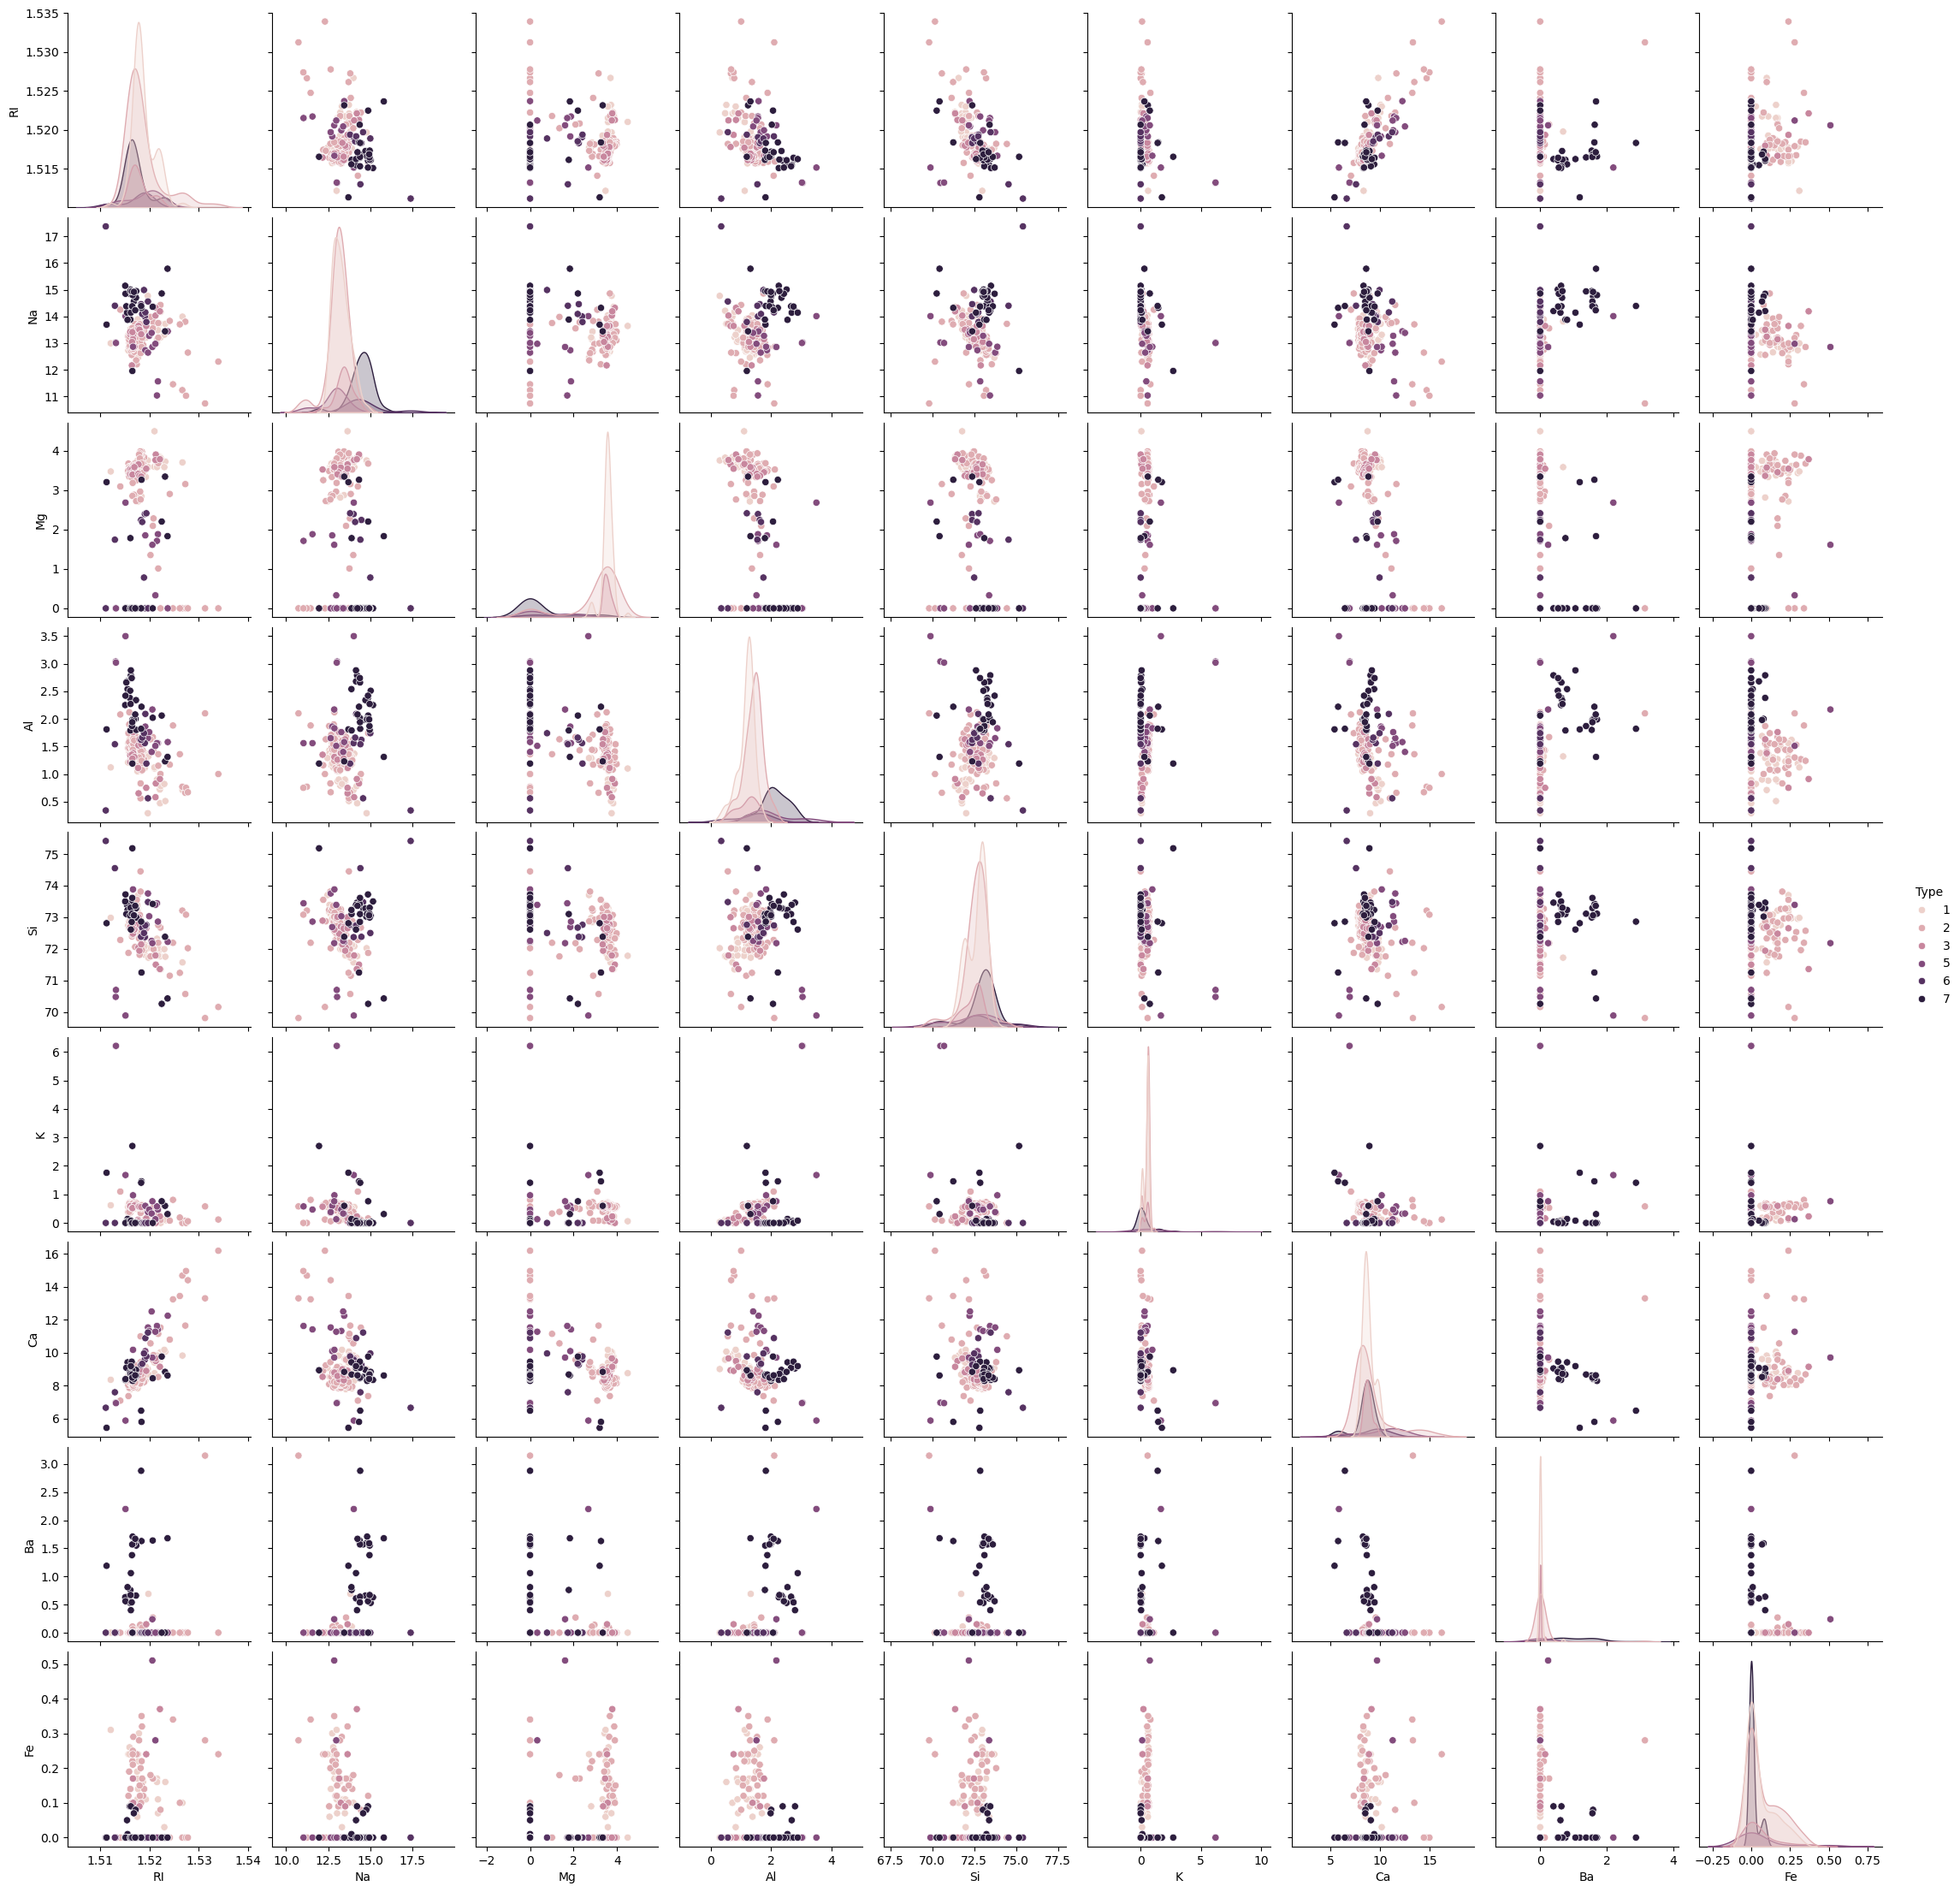

In [15]:
#pairplot
sns.pairplot(glass,hue="Type")
plt.show()

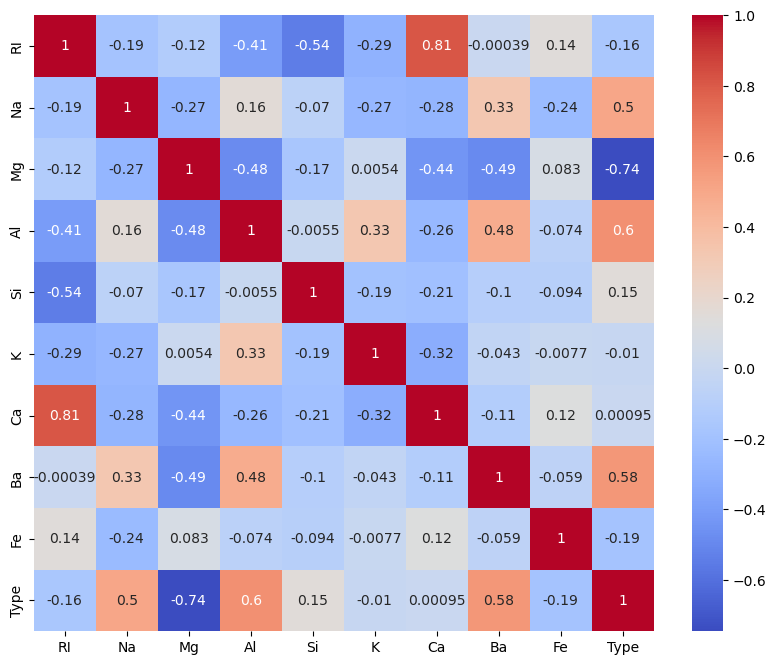

In [16]:
#Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(glass.corr(),annot=True,cmap="coolwarm")
plt.show()

# Missing value handling

In [43]:
glass.fillna(glass.mean(numeric_only=True),inplace=True)

# outlier Handling(Na Column)

In [18]:
Q1=glass["Na"].quantile(0.25)
Q3=glass["Na"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

glass["Na"]=glass["Na"].clip(lower,upper)

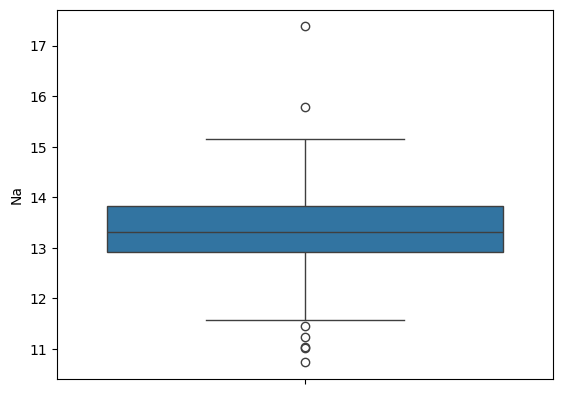

In [44]:
#check Boxplot
sns.boxplot(y=glass["Na"])
plt.show()

# Feature Scaling

In [46]:
X=glass.drop("Type",axis=1)

y=glass["Type"]

In [47]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [48]:
#scaling
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

# Handling Imbalanced Data

In [49]:
smote=SMOTE(random_state=42)

X_train,y_train=smote.fit_resample(X_train,y_train)

In [50]:
#check distribution
pd.Series(y_train).value_counts()

Type
7    61
1    61
2    61
3    61
6    61
5    61
Name: count, dtype: int64

# Random Forest Model

In [51]:
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
#prediction
y_pred=rf.predict(X_test)

In [53]:
#Accuracy
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.7441860465116279


# classification Report

In [54]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.82      0.64      0.72        14
           2       0.79      0.73      0.76        15
           3       0.29      0.67      0.40         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.74        43
   macro avg       0.76      0.81      0.76        43
weighted avg       0.80      0.74      0.76        43



# confusion matrix


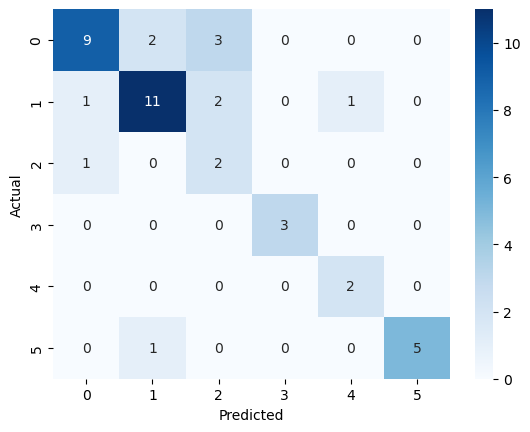

In [55]:
cm=confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# bagging method


In [56]:
bag=BaggingClassifier(random_state=42)

bag.fit(X_train,y_train)

bag_pred=bag.predict(X_test)

print("Bagging Accuracy:",accuracy_score(y_test,bag_pred))

Bagging Accuracy: 0.7674418604651163


# boosting model

In [57]:
boost=AdaBoostClassifier(random_state=42)

boost.fit(X_train,y_train)

boost_pred=boost.predict(X_test)

print("Boosting Accuracy:",accuracy_score(y_test,boost_pred))

Boosting Accuracy: 0.4883720930232558


# compare results

In [58]:
print("Random Forest :",accuracy_score(y_test,y_pred))

print("Bagging :",accuracy_score(y_test,bag_pred))

print("Boosting :",accuracy_score(y_test,boost_pred))

Random Forest : 0.7441860465116279
Bagging : 0.7674418604651163
Boosting : 0.4883720930232558


# feature importance

In [59]:
importance=pd.DataFrame({
'Feature':X.columns,
'Importance':rf.feature_importances_
})

importance=importance.sort_values(by='Importance',ascending=False)

print(importance)

  Feature  Importance
2      Mg    0.200259
5       K    0.136025
1      Na    0.129232
6      Ca    0.125679
0      RI    0.111469
3      Al    0.103703
7      Ba    0.094490
4      Si    0.081078
8      Fe    0.018066


# plot

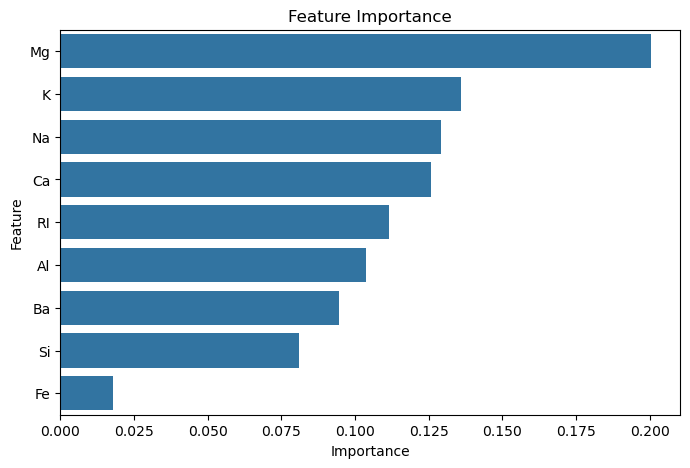

In [60]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance",y="Feature",data=importance)
plt.title("Feature Importance")
plt.show()

In [ ]:
#comparing bagging&boosting models


### 1. Explain Bagging and Boosting Methods. How are they different?
Bagging (Bootstrap Aggregating)
Bagging is an ensemble learning technique in which multiple models are trained independently using different random samples of the training data. The predictions from all models are combined (by majority voting for classification) to produce the final result. It mainly reduces variance and helps prevent overfitting.
Example: Random Forest

### Boosting:
Boosting is an ensemble learning technique where models are trained one after another.
Each new model focuses on correcting the errors made by the previous model.
The final prediction is obtained by combining the weighted predictions of all models.
It improves accuracy by reducing bias.
Examples: AdaBoost, Gradient Boosting, XGBoost.

## Difference between Bagging and Boosting
Bagging
Boosting
Models are trained independently.
Models are trained sequentially.
Uses random samples of the data.
Focuses more on previously misclassified samples.
Reduces variance and overfitting.
Reduces bias and improves accuracy.
Training can happen in parallel.
Training cannot happen in parallel.
Example: Random Forest
Examples: AdaBoost, Gradient Boosting, XGBoost

## 2. Explain how to handle imbalance in the data.
Handling Imbalanced Data: An imbalanced dataset has one class with many more samples than the other classes. This can cause the model to predict the majority class more often.
Methods to handle imbalance:
SMOTE (Synthetic Minority Over-sampling Technique):
Creates synthetic samples for the minority class to balance the dataset.
Random Oversampling:
Increases the number of minority class samples by duplicating them.
Random Undersampling:
Reduces the number of majority class samples.
Class Weights:
Assigns higher importance (weights) to minority class samples during model training.
Use Appropriate Evaluation Metrics:
Instead of only accuracy, use Precision, Recall, F1-Score, and ROC-AUC to evaluate the model.


## Conclusion: Handling imbalanced data helps the model learn all classes fairly, improves prediction of minority classes, and results in better overall performance.